<a href="https://colab.research.google.com/github/lisagamilton/python_tasks_logical/blob/main/pandas_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://drive.google.com/file/d/1xbXbLi6CyIhmWTPj6_zYysNdKEsAcVLX/view?usp=sharing

https://www.kaggle.com/datasets/arashnic/hr-analytics-job-change-of-data-scientists?resource=download

In [1]:
! gdown --id 1xbXbLi6CyIhmWTPj6_zYysNdKEsAcVLX

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1xbXbLi6CyIhmWTPj6_zYysNdKEsAcVLX
To: /content/HR_analytics.zip
100% 302k/302k [00:00<00:00, 42.7MB/s]


In [2]:
! unzip /content/HR_analytics.zip

Archive:  /content/HR_analytics.zip
  inflating: aug_test.csv            
  inflating: aug_train.csv           
  inflating: sample_submission.csv   


In [3]:
import pandas as pd
df = pd.read_csv('/content/aug_train.csv')
df

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14,NaN,NaN,1,42,1.0
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,NaN,NaN,4,52,1.0
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,4,44,0.0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,<1,500-999,Pvt Ltd,2,97,0.0


In [5]:
t = pd.DataFrame({'x':[1,2,3],'y':[1,3,2]})
t

,x,y
0,1,1
1,2,3
2,3,2


<Axes: xlabel='x', ylabel='y'>

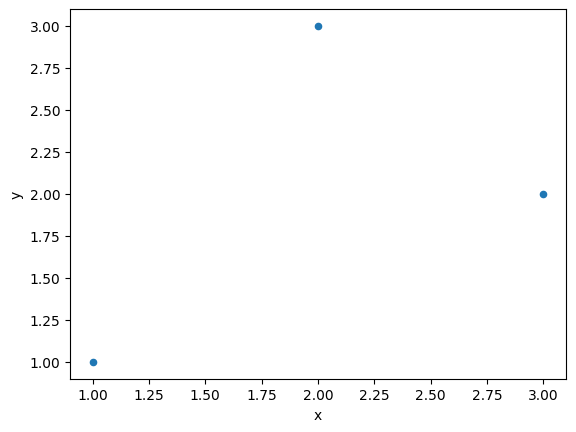

In [6]:
t.plot(x='x',y='y',kind='scatter')

In [7]:
len(df)

19158

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [40]:
df.isna().mean().sort_values(ascending=False)

,0
company_type,0.320493
company_size,0.309949
gender,0.235306
major_discipline,0.146832
education_level,0.024011
last_new_job,0.022080
enrolled_university,0.020148
experience,0.003393
relevent_experience,0.000000
enrollee_id,0.000000


In [25]:
#only 5 first people with target 1
df[df['target'] == 1].head(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
5,21651,city_176,0.764,NaN,Has relevent experience,Part time course,Graduate,STEM,11,NaN,NaN,1,24,1.0
7,402,city_46,0.762,Male,Has relevent experience,no_enrollment,Graduate,STEM,13,<10,Pvt Ltd,>4,18,1.0
8,27107,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,7,50-99,Pvt Ltd,1,46,1.0


In [24]:
#середній target по gender
df.groupby('gender')['target'].mean()

,target
gender,
Female,0.263328
Male,0.227819
Other,0.261780


In [26]:
#середній training_hours для кожного education_level
df.groupby('education_level')['training_hours'].mean()

,training_hours
education_level,
Graduate,65.773409
High School,66.680714
Masters,63.270809
Phd,67.524155
Primary School,63.626623


In [28]:
#нову колонку high_training: 1 якщо >100, 0 якщо ні
def defining_training(training_hours):
  if training_hours > 100:
    return 1
  else:
    return 0

df['high_training'] = df['training_hours'].apply(defining_training)
df

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,high_training
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0,0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0,0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0,0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0,0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14,NaN,NaN,1,42,1.0,0
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,NaN,NaN,4,52,1.0,0
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,4,44,0.0,0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,<1,500-999,Pvt Ltd,2,97,0.0,0


We could write in an easier way:

In [42]:
df['high_training'] = (df['training_hours'] > 100).astype(int)
df

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,high_training,training_hours_group
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0,0,low
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0,0,low
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0,0,medium
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0,0,medium
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0,0,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14,NaN,NaN,1,42,1.0,0,low
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,NaN,NaN,4,52,1.0,0,medium
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,4,44,0.0,0,low
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,<1,500-999,Pvt Ltd,2,97,0.0,0,medium


In [29]:
#середній target для: gender,education_level
df.groupby(['gender','education_level'])['target'].mean()

gender  education_level
Female  Graduate           0.279431
        High School        0.268657
        Masters            0.247788
        Phd                0.127660
        Primary School     0.250000
Male    Graduate           0.257122
        High School        0.182796
        Masters            0.191410
        Phd                0.132143
        Primary School     0.093596
Other   Graduate           0.330357
        High School        0.181818
        Masters            0.074074
        Phd                0.250000
        Primary School     0.333333
Name: target, dtype: float64

In [33]:
#Створи групи для training_hours: low (<50), medium (50–100), high (>100)
#і порівняй: середній target
def grouping_hours(training_hours):
  if training_hours > 100:
    return 'high'
  if training_hours < 50:
    return 'low'
  else:
    return 'medium'

df['training_hours_group'] = df['training_hours'].apply(grouping_hours)
df.groupby('training_hours_group')['target'].mean()

,target
training_hours_group,
high,0.238366
low,0.254186
medium,0.248326


Можна чистіше:

In [46]:
df['training_group'] = pd.cut(
    df['training_hours'],
    bins=[0,50,100,400],
    labels=['low','medium','high']
)

In [43]:
#Знайди: топ-5 міст (city) з найбільшим target
df.groupby('city')['target'].mean().sort_values(ascending=False).head(5)

,target
city,
city_171,1.000000
city_139,0.800000
city_155,0.785714
city_42,0.692308
city_107,0.666667


In [48]:
df['city'].value_counts()

,count
city,
city_103,4355
city_21,2702
city_16,1533
city_114,1336
city_160,845
...,...
city_111,3
city_129,3
city_121,3


In [39]:
#pivot table
df.pivot_table(index='education_level',columns='gender',values='target',aggfunc='mean')

gender,Female,Male,Other
education_level,,,
Graduate,0.279431,0.257122,0.330357
High School,0.268657,0.182796,0.181818
Masters,0.247788,0.191410,0.074074
Phd,0.127660,0.132143,0.250000
Primary School,0.250000,0.093596,0.333333
